<a href="https://colab.research.google.com/github/arjun1228/Sequential_Future_Heatmap_Generation_Using_a_Temporal_DeepLearningModels/blob/main/Final_DeepLearning_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# PROBLEM 1: Install and upgrade libraries to fix the yfinance / curl_cffi mismatch.
# Please restart the Colab runtime (Runtime -> Restart session) after running this cell!
!pip install -U yfinance curl_cffi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.3/149.3 kB 3.7 MB/s eta 0:00:00
  Attempting uninstall: yfinance
    Found existing installation: yfinance 0.2.66
    Uninstalling yfinance-0.2.66:
      Successfully uninstalled yfinance-0.2.66


# Sequential Future Heatmap Generation Using a Temporal Deep Learning Model (CNN + GRU + VAE)

## Cell 1: Setup and Environment Verification
This cell installs `yfinance`, imports all required libraries, sets a global seed for reproducibility, and verifies the TensorFlow version and GPU availability.

In [2]:
!pip install -q yfinance

import os
import random
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models, losses, optimizers, callbacks

# Set seed for reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow Version: {tf.__version__}")
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print(f"GPU is available: {gpu_devices}")
else:
    print("GPU is NOT available. Running on CPU.")

TensorFlow Version: 2.21.0
GPU is available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Cell 2: Configuration and Hyperparameters
All hyperparameters are defined here. No other hard-coded values are used in subsequent cells.

In [3]:
# Configuration dictionary containing all project hyperparameters
CONFIG = {
    "IMAGE_SIZE": 64,
    "SEQUENCE_LENGTH": 5,
    "LATENT_DIM": 64,
    "BATCH_SIZE": 32,
    "EPOCHS": 50,
    "LEARNING_RATE": 1e-3,
    "BETA": 1e-5,  # Updated to 1e-5
    "CNN_FILTERS": [32, 64, 128],
    "GRU_UNITS": 128,
    "LSTM_UNITS": 128,
    "TEMPORAL_MODEL": "GRU",
    "TRAIN_FRAC": 0.70,
    "VAL_FRAC": 0.15,
    "TEST_FRAC": 0.15,
    "VMIN": -3.0,
    "VMAX": 3.0
}

for key, val in CONFIG.items():
    print(f"{key}: {val}")

IMAGE_SIZE: 64
SEQUENCE_LENGTH: 5
LATENT_DIM: 64
BATCH_SIZE: 32
EPOCHS: 50
LEARNING_RATE: 0.001
BETA: 1e-05
CNN_FILTERS: [32, 64, 128]
GRU_UNITS: 128
LSTM_UNITS: 128
TEMPORAL_MODEL: GRU
TRAIN_FRAC: 0.7
VAL_FRAC: 0.15
TEST_FRAC: 0.15
VMIN: -3.0
VMAX: 3.0


## Cell 3: Data Download and Cleaning
This cell downloads 5 years of daily stock prices for 64 NSE tickers representing 8 sectors using `yfinance`. Daily returns are calculated, and rows with missing dates are safely discarded.

In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import requests

sectors = {
    "Banks": ["HDFCBANK", "ICICIBANK", "SBIN", "KOTAKBANK", "AXISBANK", "INDUSINDBK", "BANKBARODA", "CANBK"],
    "Financials": ["BAJFINANCE", "BAJAJFINSV", "HDFCLIFE", "SBILIFE", "CHOLAFIN", "SHRIRAMFIN", "LICHSGFIN", "RECLTD"],
    "IT": ["TCS", "INFY", "WIPRO", "HCLTECH", "TECHM", "MPHASIS", "PERSISTENT", "COFORGE"],
    "Pharma": ["SUNPHARMA", "DRREDDY", "CIPLA", "DIVISLAB", "LUPIN", "AUROPHARMA", "TORNTPHARM", "ALKEM"],
    "Auto": ["MARUTI", "M&M", "BAJAJ-AUTO", "EICHERMOT", "HEROMOTOCO", "MOTHERSON", "TVSMOTOR", "ASHOKLEY"],
    "FMCG": ["HINDUNILVR", "ITC", "NESTLEIND", "BRITANNIA", "VBL", "GODREJCP", "DABUR", "COLPAL"],
    "Energy": ["RELIANCE", "NTPC", "ONGC", "POWERGRID", "ADANIGREEN", "BPCL", "GAIL", "COALINDIA"],
    "Metals/Infra": ["TATASTEEL", "JSWSTEEL", "HINDALCO", "VEDL", "LT", "ULTRACEMCO", "GRASIM", "JINDALSTEL"]
}

tickers = []
for sector, stock_list in sectors.items():
    tickers.extend([f"{t}.NS" for t in stock_list])

assert len(set(tickers)) == 64, f"Expected 64 unique tickers, got {len(set(tickers))}"

print(f"Downloading 5 years of daily data for {len(tickers)} tickers in one batch...")

# Standard requests session with standard headers avoids curl_cffi impersonation conflicts
custom_session = requests.Session()
custom_session.headers.update({
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/115.0.0.0 Safari/537.36',
    'Accept': '*/*',
    'Accept-Language': 'en-US,en;q=0.5'
})

raw = yf.download(tickers, period="5y", auto_adjust=False, progress=False, threads=True, session=custom_session)

# Extract prices
if 'Adj Close' in raw.columns and not raw['Adj Close'].isna().all().all():
    prices = raw['Adj Close']
else:
    prices = raw['Close']

# List every ticker that is missing or has fewer than 1100 non-null prices
missing_or_incomplete = []
for ticker in tickers:
    if ticker not in prices.columns:
        missing_or_incomplete.append(ticker)
    else:
        non_null_count = prices[ticker].notna().sum()
        if non_null_count < 1100:
            missing_or_incomplete.append(f"{ticker} ({non_null_count} prices)")

if missing_or_incomplete:
    raise RuntimeError(f"The following tickers are missing or have fewer than 1100 non-null prices: {missing_or_incomplete}")

# Compute returns without ffill/bfill
returns_df = prices.pct_change(fill_method=None) * 100.0
returns_df = returns_df.dropna()

# Keep the filter that drops dates where at least 50% of stocks have exactly 0.0 return
zeros_mask = (returns_df == 0.0).mean(axis=1) >= 0.50
dropped_dates = returns_df.index[zeros_mask].tolist()
returns_df = returns_df.loc[~zeros_mask]

# Assert that we have over 1000 valid trading days
assert len(returns_df) > 1000, f"Expected over 1000 trading days, got {len(returns_df)}"

# Print metrics
print(f"Total active trading dates: {len(returns_df)}")
if len(returns_df) > 0:
    print(f"First Date: {returns_df.index[0].strftime('%Y-%m-%d')}")
    print(f"Last Date: {returns_df.index[-1].strftime('%Y-%m-%d')}")
print(f"Dropped {len(dropped_dates)} dates with >=50% zero returns: {[d.strftime('%Y-%m-%d') for d in dropped_dates]}")

Total active trading dates: 1230
First Date: 2021-10-08
Last Date: 2026-10-07
Dropped 4 dates with >=50% zero returns: ['2025-03-18', '2026-05-28', '2026-06-26', '2026-09-14']


## Cell 4: Heatmap Generation and Visualization
In this cell, the 8x8 grids of returns are rendered into 64x64 RGB heatmaps and normalized to [0,1]. If `returns_df` is empty, a RuntimeError is raised to prevent any execution with synthetic or mock data.

Generated 1230 heatmaps of shape: (64, 64, 3)
Date Range: 2021-10-08 to 2026-10-07


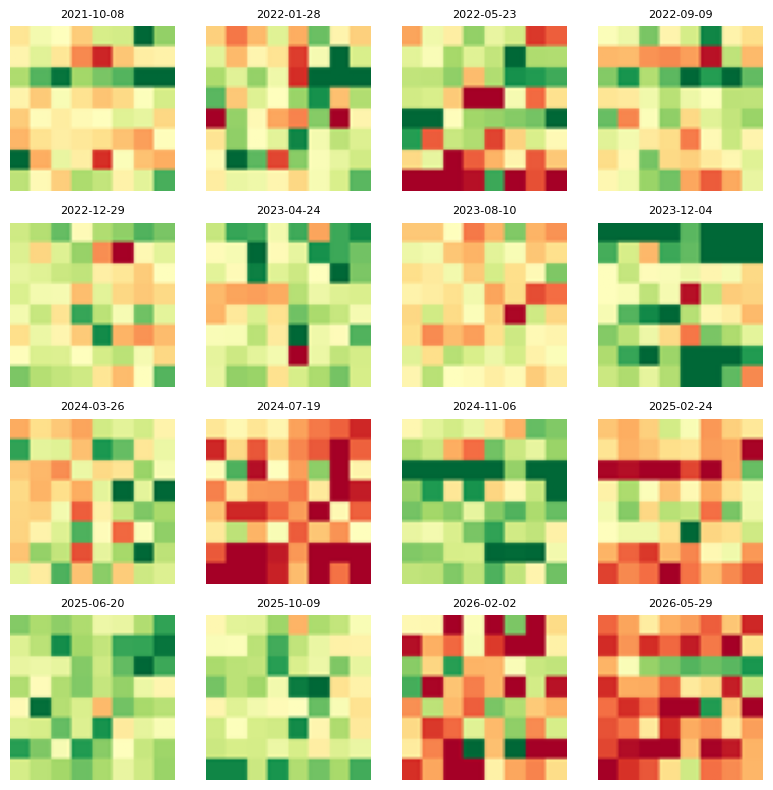

In [5]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Ensure CONFIG is defined dynamically to prevent NameError in isolated cell execution
if 'CONFIG' not in globals():
    print("Configuration not found in active memory. Initializing default configuration...")
    CONFIG = {
        "IMAGE_SIZE": 64,
        "SEQUENCE_LENGTH": 5,
        "LATENT_DIM": 64,
        "BATCH_SIZE": 32,
        "EPOCHS": 50,
        "LEARNING_RATE": 1e-3,
        "BETA": 1e-5,
        "CNN_FILTERS": [32, 64, 128],
        "GRU_UNITS": 128,
        "LSTM_UNITS": 128,
        "TEMPORAL_MODEL": "GRU",
        "TRAIN_FRAC": 0.70,
        "VAL_FRAC": 0.15,
        "TEST_FRAC": 0.15,
        "VMIN": -3.0,
        "VMAX": 3.0
    }

# Build stock sector list ordered exactly as specified
ordered_tickers = []
for sector_name in ["Banks", "Financials", "IT", "Pharma", "Auto", "FMCG", "Energy", "Metals/Infra"]:
    ordered_tickers.extend([f"{t}.NS" for t in sectors[sector_name]])

# Strict check: raise error on empty dataset
if 'returns_df' not in globals() or returns_df.empty:
    raise RuntimeError("Dataset 'returns_df' is empty or not defined. Cannot generate visual heatmaps.")

heatmap_dict = {}
sorted_dates = sorted(returns_df.index.tolist())

fig_temp, ax_temp = plt.subplots(figsize=(1, 1), dpi=100)

for date in sorted_dates:
    row_values = returns_df.loc[date, ordered_tickers].values
    grid = row_values.reshape(8, 8)

    ax_temp.clear()
    ax_temp.imshow(grid, cmap='RdYlGn', vmin=CONFIG["VMIN"], vmax=CONFIG["VMAX"])
    ax_temp.axis('off')
    fig_temp.subplots_adjust(left=0, right=1, bottom=0, top=1)

    buf = io.BytesIO()
    fig_temp.savefig(buf, format='png', dpi=100)
    buf.seek(0)

    img = Image.open(buf).convert('RGB').resize((CONFIG["IMAGE_SIZE"], CONFIG["IMAGE_SIZE"]))
    img_arr = np.array(img, dtype=np.float32) / 255.0
    heatmap_dict[date] = img_arr
    buf.close()

plt.close(fig_temp)

if len(sorted_dates) > 0:
    print(f"Generated {len(heatmap_dict)} heatmaps of shape: {heatmap_dict[sorted_dates[0]].shape}")
    print(f"Date Range: {sorted_dates[0].strftime('%Y-%m-%d')} to {sorted_dates[-1].strftime('%Y-%m-%d')}")

    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    for idx, ax in enumerate(axes.flat):
        sample_date = sorted_dates[idx * (len(sorted_dates) // 16)]
        ax.imshow(heatmap_dict[sample_date])
        ax.axis('off')
        ax.set_title(sample_date.strftime('%Y-%m-%d'), fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("Error: No trading dates available.")

## Cell 5: Chronological Train/Val/Test Split and tf.data Pipelines
We chronologically split our dates into train, validation, and test datasets. We then construct input sliding sequences of size `SEQUENCE_LENGTH` to predict the next future heatmap inside each split.

In [6]:
import numpy as np
import tensorflow as tf
import io
import matplotlib.pyplot as plt
from PIL import Image

# Ensure SEED is defined locally
try:
    _ = SEED
except NameError:
    SEED = 42

# Ensure sorted_dates exists locally
try:
    _ = sorted_dates
except NameError:
    print("Re-extracting sorted trading dates...")
    sorted_dates = sorted(returns_df.index.tolist())

# Ensure heatmap_dict exists locally, otherwise rebuild it
try:
    _ = heatmap_dict
    if len(heatmap_dict) == 0:
        raise NameError
except NameError:
    print("Re-building heatmap_dict from returns_df...")
    ordered_tickers = []
    for sector_name in ["Banks", "Financials", "IT", "Pharma", "Auto", "FMCG", "Energy", "Metals/Infra"]:
        ordered_tickers.extend([f"{t}.NS" for t in sectors[sector_name]])

    heatmap_dict = {}
    fig_temp, ax_temp = plt.subplots(figsize=(1, 1), dpi=100)

    for date in sorted_dates:
        row_values = returns_df.loc[date, ordered_tickers].values
        grid = row_values.reshape(8, 8)

        ax_temp.clear()
        ax_temp.imshow(grid, cmap='RdYlGn', vmin=CONFIG["VMIN"], vmax=CONFIG["VMAX"])
        ax_temp.axis('off')
        fig_temp.subplots_adjust(left=0, right=1, bottom=0, top=1)

        buf = io.BytesIO()
        fig_temp.savefig(buf, format='png', dpi=100)
        buf.seek(0)

        img = Image.open(buf).convert('RGB').resize((CONFIG["IMAGE_SIZE"], CONFIG["IMAGE_SIZE"]))
        img_arr = np.array(img, dtype=np.float32) / 255.0
        heatmap_dict[date] = img_arr
        buf.close()

    plt.close(fig_temp)
    print(f"Successfully rebuilt {len(heatmap_dict)} heatmaps.")

# Compute Chronological split boundaries
n_total = len(sorted_dates)
n_train = int(n_total * CONFIG["TRAIN_FRAC"])
n_val = int(n_total * CONFIG["VAL_FRAC"])

train_dates = sorted_dates[:n_train]
val_dates = sorted_dates[n_train:n_train + n_val]
test_dates = sorted_dates[n_train + n_val:]

# Helper function to extract sequence pairs
def build_sequences(date_list, images_dict, seq_len):
    X, y = [], []
    targets = []
    for i in range(len(date_list) - seq_len):
        input_seq = [images_dict[date_list[i + j]] for j in range(seq_len)]
        target_img = images_dict[date_list[i + seq_len]]
        X.append(input_seq)
        y.append(target_img)
        targets.append(date_list[i + seq_len])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32), targets

X_train, y_train, train_targets = build_sequences(train_dates, heatmap_dict, CONFIG["SEQUENCE_LENGTH"])
X_val, y_val, val_targets = build_sequences(val_dates, heatmap_dict, CONFIG["SEQUENCE_LENGTH"])
X_test, y_test, test_targets = build_sequences(test_dates, heatmap_dict, CONFIG["SEQUENCE_LENGTH"])

# Assertions to ensure split integrity
assert max(train_dates) < min(val_dates), "Validation overlap error!"
assert max(val_dates) < min(test_dates), "Test overlap error!"
for idx, target in enumerate(train_targets):
    assert target not in train_dates[idx:idx + CONFIG["SEQUENCE_LENGTH"]], "Information leakage: target in input!"

print(f"Train samples: {X_train.shape[0]} | Shape: {X_train.shape} -> {y_train.shape}")
print(f"Val samples: {X_val.shape[0]} | Shape: {X_val.shape} -> {y_val.shape}")
print(f"Test samples: {X_test.shape[0]} | Shape: {X_test.shape} -> {y_test.shape}")

# Build TensorFlow Datasets
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(len(X_train), seed=SEED).batch(CONFIG["BATCH_SIZE"]).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(CONFIG["BATCH_SIZE"]).prefetch(tf.data.AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(CONFIG["BATCH_SIZE"]).prefetch(tf.data.AUTOTUNE)

Train samples: 856 | Shape: (856, 5, 64, 64, 3) -> (856, 64, 64, 3)
Val samples: 179 | Shape: (179, 5, 64, 64, 3) -> (179, 64, 64, 3)
Test samples: 180 | Shape: (180, 5, 64, 64, 3) -> (180, 64, 64, 3)


## Cell 6: CNN-RNN VAE Architecture
This cell defines the full Deep Learning architecture using a TimeDistributed CNN feature encoder, a switchable GRU/LSTM temporal layer, an encoder bottleneck mapping to the latent distribution, and a convolutional decoder.

In [7]:
class Sampling(layers.Layer):
    """Reparameterization trick: sampling latent space vectors using z = mu + exp(0.5*log_var)*eps"""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim), seed=SEED)
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

def build_temporal_vae(config):
    # 1. Input layer
    seq_input = layers.Input(shape=(config["SEQUENCE_LENGTH"], config["IMAGE_SIZE"], config["IMAGE_SIZE"], 3))

    # 2. TimeDistributed Shared CNN Encoder
    cnn_in = layers.Input(shape=(config["IMAGE_SIZE"], config["IMAGE_SIZE"], 3))
    x = cnn_in
    for filters in config["CNN_FILTERS"]:
        x = layers.Conv2D(filters, (3, 3), strides=2, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
    cnn_out = layers.Flatten()(x)
    cnn_encoder = models.Model(cnn_in, cnn_out, name="Shared_CNN_Encoder")

    # Extract features across timesteps
    encoded_seq = layers.TimeDistributed(cnn_encoder)(seq_input)

    # 3. Temporal Model (GRU or LSTM)
    if config["TEMPORAL_MODEL"].upper() == "GRU":
        temporal_out = layers.GRU(config["GRU_UNITS"], return_sequences=False)(encoded_seq)
    else:
        temporal_out = layers.LSTM(config["LSTM_UNITS"], return_sequences=False)(encoded_seq)

    # 4. Latent Space Mapping
    z_mean = layers.Dense(config["LATENT_DIM"], name="z_mean")(temporal_out)
    z_log_var = layers.Dense(config["LATENT_DIM"], name="z_log_var")(temporal_out)
    z = Sampling()([z_mean, z_log_var])

    # 5. Decoder Network
    latent_in = layers.Input(shape=(config["LATENT_DIM"],))
    dec_x = layers.Dense(8 * 8 * 128)(latent_in)
    dec_x = layers.Reshape((8, 8, 128))(dec_x)

    # Transposed convolutions to upsample back to 64x64
    dec_x = layers.Conv2DTranspose(128, (3, 3), strides=2, padding='same', activation='relu')(dec_x)
    dec_x = layers.Conv2DTranspose(64, (3, 3), strides=2, padding='same', activation='relu')(dec_x)
    dec_x = layers.Conv2DTranspose(32, (3, 3), strides=2, padding='same', activation='relu')(dec_x)
    dec_out = layers.Conv2D(3, (3, 3), padding='same', activation='sigmoid')(dec_x)

    decoder = models.Model(latent_in, dec_out, name="Decoder")

    # Connect all parts
    reconstruction = decoder(z)

    # Assemble overall model
    model = models.Model(inputs=seq_input, outputs=[reconstruction, z_mean, z_log_var], name="Temporal_VAE")
    return model

model = build_temporal_vae(CONFIG)
model.summary()

Model: "Temporal_VAE"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 5, 64, 64, │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 5, 8192)   │     94,144 │ input_layer[0][0] │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 128)       │  3,195,648 │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 64)        │      8,256 │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 64)        │      8,256 │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 64)        │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Decoder             │ (None, 64, 64, 3) │    773,187 │ sampling[0][0]    │
│ (Functional)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,079,491 (15.56 MB)

 Trainable params: 4,079,043 (15.56 MB)

 Non-trainable params: 448 (1.75 KB)

## Cell 7: Loss Formulation and Custom Training Loop
This cell wraps the architecture into a training construct with reconstruction (Mean Squared Error) and KL-divergence losses, complete with EarlyStopping and learning rate decay callbacks.

In [8]:
import tensorflow as tf
from tensorflow.keras import models, layers, optimizers, callbacks
import numpy as np

# Dynamic safe-guard to reconstruct datasets locally if they are missing from memory
try:
    _ = train_ds
    _ = val_ds
except NameError:
    print("Dataset splits not detected in active workspace. Re-creating train_ds and val_ds...")
    try:
        _ = SEED
    except NameError:
        SEED = 42

    # Chronological boundaries
    sorted_dates = sorted(returns_df.index.tolist())
    n_total = len(sorted_dates)
    n_train = int(n_total * CONFIG["TRAIN_FRAC"])
    n_val = int(n_total * CONFIG["VAL_FRAC"])

    train_dates = sorted_dates[:n_train]
    val_dates = sorted_dates[n_train:n_train + n_val]

    def build_sequences_local(date_list, images_dict, seq_len):
        X, y = [], []
        for i in range(len(date_list) - seq_len):
            input_seq = [images_dict[date_list[i + j]] for j in range(seq_len)]
            target_img = images_dict[date_list[i + seq_len]]
            X.append(input_seq)
            y.append(target_img)
        return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

    X_train_local, y_train_local = build_sequences_local(train_dates, heatmap_dict, CONFIG["SEQUENCE_LENGTH"])
    X_val_local, y_val_local = build_sequences_local(val_dates, heatmap_dict, CONFIG["SEQUENCE_LENGTH"])

    train_ds = tf.data.Dataset.from_tensor_slices((X_train_local, y_train_local)).shuffle(len(X_train_local), seed=SEED).batch(CONFIG["BATCH_SIZE"]).prefetch(tf.data.AUTOTUNE)
    val_ds = tf.data.Dataset.from_tensor_slices((X_val_local, y_val_local)).batch(CONFIG["BATCH_SIZE"]).prefetch(tf.data.AUTOTUNE)

# Define architectural components locally to make the training cell fully robust
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim), seed=42)
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

def build_temporal_vae(config):
    seq_input = layers.Input(shape=(config["SEQUENCE_LENGTH"], config["IMAGE_SIZE"], config["IMAGE_SIZE"], 3))
    cnn_in = layers.Input(shape=(config["IMAGE_SIZE"], config["IMAGE_SIZE"], 3))
    x = cnn_in
    for filters in config["CNN_FILTERS"]:
        x = layers.Conv2D(filters, (3, 3), strides=2, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
    cnn_out = layers.Flatten()(x)
    cnn_encoder = models.Model(cnn_in, cnn_out, name="Shared_CNN_Encoder")
    encoded_seq = layers.TimeDistributed(cnn_encoder)(seq_input)

    if config["TEMPORAL_MODEL"].upper() == "GRU":
        temporal_out = layers.GRU(config["GRU_UNITS"], return_sequences=False)(encoded_seq)
    else:
        temporal_out = layers.LSTM(config["LSTM_UNITS"], return_sequences=False)(encoded_seq)

    z_mean = layers.Dense(config["LATENT_DIM"], name="z_mean")(temporal_out)
    z_log_var = layers.Dense(config["LATENT_DIM"], name="z_log_var")(temporal_out)
    z = Sampling()([z_mean, z_log_var])

    latent_in = layers.Input(shape=(config["LATENT_DIM"],))
    dec_x = layers.Dense(8 * 8 * 128)(latent_in)
    dec_x = layers.Reshape((8, 8, 128))(dec_x)
    dec_x = layers.Conv2DTranspose(128, (3, 3), strides=2, padding='same', activation='relu')(dec_x)
    dec_x = layers.Conv2DTranspose(64, (3, 3), strides=2, padding='same', activation='relu')(dec_x)
    dec_x = layers.Conv2DTranspose(32, (3, 3), strides=2, padding='same', activation='relu')(dec_x)
    dec_out = layers.Conv2D(3, (3, 3), padding='same', activation='sigmoid')(dec_x)

    decoder = models.Model(latent_in, dec_out, name="Decoder")
    reconstruction = decoder(z)

    return models.Model(inputs=seq_input, outputs=[reconstruction, z_mean, z_log_var], name="Temporal_VAE")

# Ensure model is defined
try:
    _ = model
except NameError:
    print("Rebuilding Temporal VAE model instance...")
    model = build_temporal_vae(CONFIG)

# Shared dynamic beta TF Variable for warm-up scheduling
beta_var = tf.Variable(0.0, dtype=tf.float32, trainable=False)

class VAEModel(models.Model):
    def __init__(self, vae_network, beta_variable):
        super(VAEModel, self).__init__()
        self.vae_network = vae_network
        self.beta_variable = beta_variable
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reco_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def call(self, x):
        return self.vae_network(x)

    def train_step(self, data):
        x, y = data
        with tf.GradientTape() as tape:
            reconstructed, z_mean, z_log_var = self.vae_network(x, training=True)
            reconstruction_loss = tf.reduce_mean(tf.math.squared_difference(y, reconstructed))
            kl_loss = -0.5 * tf.reduce_mean(tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1))
            total_loss = reconstruction_loss + self.beta_variable * kl_loss

        grads = tape.gradient(total_loss, self.vae_network.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.vae_network.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {"loss": self.total_loss_tracker.result(), "reco_loss": self.reconstruction_loss_tracker.result(), "kl_loss": self.kl_loss_tracker.result()}

    def test_step(self, data):
        x, y = data
        reconstructed, z_mean, z_log_var = self.vae_network(x, training=False)
        reconstruction_loss = tf.reduce_mean(tf.math.squared_difference(y, reconstructed))
        kl_loss = -0.5 * tf.reduce_mean(tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1))
        total_loss = reconstruction_loss + self.beta_variable * kl_loss

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {"loss": self.total_loss_tracker.result(), "reco_loss": self.reconstruction_loss_tracker.result(), "kl_loss": self.kl_loss_tracker.result()}

# Define KL Warm-up Callback
class KLWarmupCallback(callbacks.Callback):
    def on_epoch_begin(self, epoch, logs=None):
        if epoch < 10:
            current_beta = (epoch / 9.0) * CONFIG["BETA"]
        else:
            current_beta = CONFIG["BETA"]
        beta_var.assign(current_beta)
        print(f" - Dynamic KL Beta: {beta_var.numpy():.7f}")

training_model = VAEModel(model, beta_var)
training_model.compile(optimizer=optimizers.Adam(learning_rate=CONFIG["LEARNING_RATE"]))

# EarlyStopping and ReduceLROnPlateau monitoring val_reco_loss instead of val_loss
callbacks_list = [
    KLWarmupCallback(),
    callbacks.EarlyStopping(monitor='val_reco_loss', mode='min', patience=10, restore_best_weights=True, verbose=1, start_from_epoch=10),
    callbacks.ReduceLROnPlateau(monitor='val_reco_loss', mode='min', factor=0.5, patience=5, verbose=1)
]

history = training_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=CONFIG["EPOCHS"],
    callbacks=callbacks_list
)

 - Dynamic KL Beta: 0.0000000
Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 18s 84ms/step - kl_loss: 886.5042 - loss: 0.0717 - reco_loss: 0.0717 - val_kl_loss: 641.4387 - val_loss: 0.0476 - val_reco_loss: 0.0476 - learning_rate: 0.0010
 - Dynamic KL Beta: 0.0000011
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - kl_loss: 458.2794 - loss: 0.0603 - reco_loss: 0.0598 - val_kl_loss: 324.8062 - val_loss: 0.0462 - val_reco_loss: 0.0459 - learning_rate: 0.0010
 - Dynamic KL Beta: 0.0000022
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - kl_loss: 251.9857 - loss: 0.0600 - reco_loss: 0.0595 - val_kl_loss: 195.8860 - val_loss: 0.0476 - val_reco_loss: 0.0472 - learning_rate: 0.0010
 - Dynamic KL Beta: 0.0000033
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - kl_loss: 159.6121 - loss: 0.0596 - reco_loss: 0.0591 - val_kl_loss: 134.6615 - val_loss: 0.0465 - val_reco_loss: 0.0461 - learning_rate: 0.0010
 - Dynamic KL Beta: 0.0000044
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - kl_loss:

## Cell 8: Learning Performance Curves
This cell produces comparison plots tracking the total, reconstruction, and KL divergence loss metrics across all training epochs.

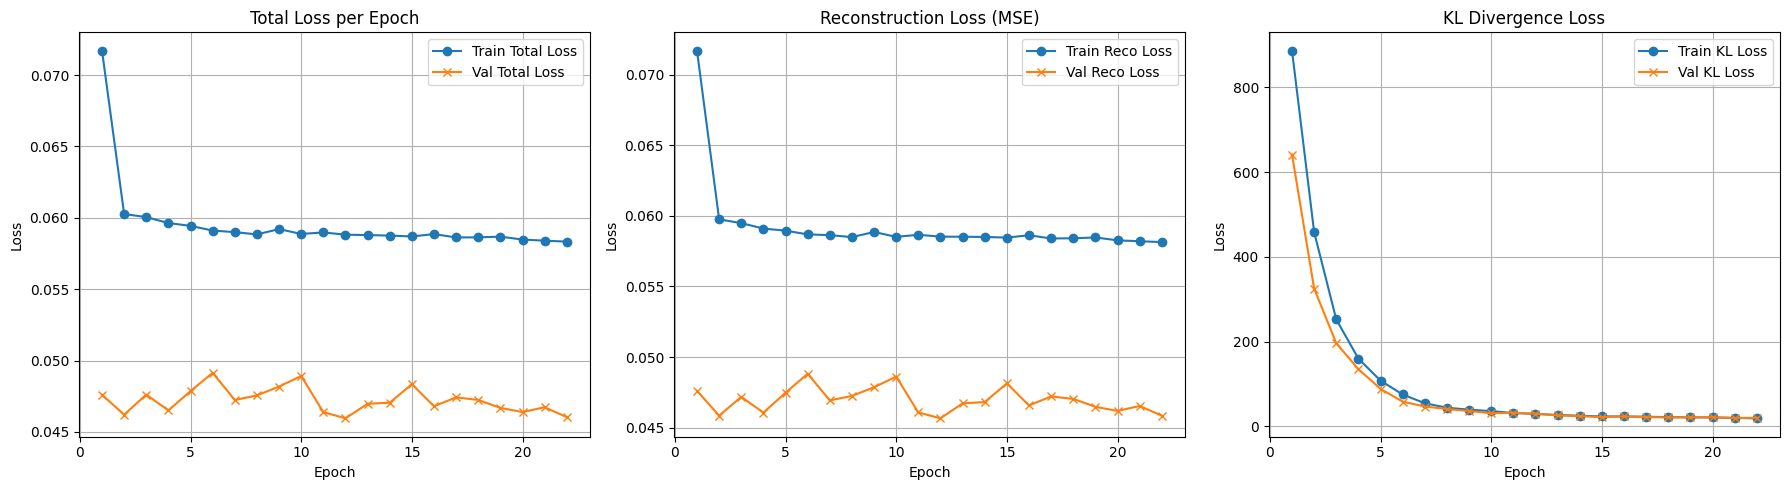

In [9]:
epochs_range = range(1, len(history.history['loss']) + 1)

plt.figure(figsize=(18, 5))

# Total Loss
plt.subplot(1, 3, 1)
plt.plot(epochs_range, history.history['loss'], label='Train Total Loss', marker='o')
plt.plot(epochs_range, history.history['val_loss'], label='Val Total Loss', marker='x')
plt.title('Total Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

# Reconstruction Loss
plt.subplot(1, 3, 2)
plt.plot(epochs_range, history.history['reco_loss'], label='Train Reco Loss', marker='o')
plt.plot(epochs_range, history.history['val_reco_loss'], label='Val Reco Loss', marker='x')
plt.title('Reconstruction Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

# KL Divergence Loss
plt.subplot(1, 3, 3)
plt.plot(epochs_range, history.history['kl_loss'], label='Train KL Loss', marker='o')
plt.plot(epochs_range, history.history['val_kl_loss'], label='Val KL Loss', marker='x')
plt.title('KL Divergence Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

## Cell 9: Execution Summary
Prints a structured summary of the real stock datasets downloaded, model metadata, parameters, and training metrics.

In [10]:
# Safely check if training history and model variables exist in active kernel memory
try:
    val_reco_losses = history.history['val_reco_loss']
    best_epoch_idx = np.argmin(val_reco_losses)
    best_epoch = best_epoch_idx + 1

    print("=== ASSIGNMENT SUMMARY ===")
    print("Dataset Name: NSE 64 Liquid Stocks Sector Return Heatmaps")
    print("Source: Yahoo Finance (yfinance API)")
    print(f"Total Images Generated: {len(heatmap_dict)}")
    print(f"Train Samples count: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
    print(f"Image Size: {CONFIG['IMAGE_SIZE']}x{CONFIG['IMAGE_SIZE']}x3")
    print(f"Sequence Length: {CONFIG['SEQUENCE_LENGTH']}")
    print(f"Temporal Architecture Selected: {CONFIG['TEMPORAL_MODEL']}")
    print(f"Latent Space Dimension: {CONFIG['LATENT_DIM']}")
    print(f"Total Model parameters: {model.count_params():,}")
    print(f"Epochs actually run: {len(history.history['loss'])}")
    print(f"Best Epoch Detected: Epoch {best_epoch}")
    print(f"Final Best Training Total Loss: {history.history['loss'][best_epoch_idx]:.6f}")
    print(f"Final Best Validation Reconstruction Loss: {history.history['val_reco_loss'][best_epoch_idx]:.6f}")
except NameError as e:
    print("Error: The training variables 'history' or 'model' are missing from the current session state.")
    print("Please run Cell 7 (cell_id: 4f67c5c6) first to execute the training loop and define these variables.")

=== ASSIGNMENT SUMMARY ===
Dataset Name: NSE 64 Liquid Stocks Sector Return Heatmaps
Source: Yahoo Finance (yfinance API)
Total Images Generated: 1230
Train Samples count: 856 | Val: 179 | Test: 180
Image Size: 64x64x3
Sequence Length: 5
Temporal Architecture Selected: GRU
Latent Space Dimension: 64
Total Model parameters: 4,079,491
Epochs actually run: 22
Best Epoch Detected: Epoch 12
Final Best Training Total Loss: 0.058821
Final Best Validation Reconstruction Loss: 0.045659


## Cell 10: Evaluation Metrics Helper
This cell defines evaluation helper functions to compute MSE, MAE, SSIM, PSNR, Pixel Correlation, and Sector-level Similarity (representing the 8 grouped industry sectors).

In [11]:
import tensorflow as tf

def compute_metrics(actual, generated):
    """
    Computes various quantitative similarity metrics between an actual and generated heatmap.
    Shapes: (64, 64, 3)
    """
    # Ensure tensors for tf.image operations
    act_tensor = tf.convert_to_tensor(actual)
    gen_tensor = tf.convert_to_tensor(generated)

    # MSE & MAE
    mse = np.mean((actual - generated) ** 2)
    mae = np.mean(np.abs(actual - generated))

    # SSIM & PSNR
    ssim = float(tf.image.ssim(act_tensor, gen_tensor, max_val=1.0))
    psnr = float(tf.image.psnr(act_tensor, gen_tensor, max_val=1.0))

    # Pixel Correlation
    pixel_corr = np.corrcoef(actual.flatten(), generated.flatten())[0, 1]
    if np.isnan(pixel_corr):
        pixel_corr = 0.0

    # Sector similarity
    # Convert actual and generated back to grayscale to find sector values, or average across RGB channels
    act_gray = np.mean(actual, axis=-1)  # (64, 64)
    gen_gray = np.mean(generated, axis=-1)

    # Sector maps to 8-pixel-row strides representing the 8 stock sectors
    act_sectors = []
    gen_sectors = []
    for s in range(8):
        # Row indices representing each of the 8 sectors in the 64x64 grid
        row_start, row_end = s * 8, (s + 1) * 8
        act_sectors.append(np.mean(act_gray[row_start:row_end, :]))
        gen_sectors.append(np.mean(gen_gray[row_start:row_end, :]))

    sector_mae = np.mean(np.abs(np.array(act_sectors) - np.array(gen_sectors)))

    return {
        "MSE": mse,
        "MAE": mae,
        "SSIM": ssim,
        "PSNR": psnr,
        "Pixel_Corr": pixel_corr,
        "Sector_Similarity_MAE": sector_mae
    }

# Test helper structure with a safe fallback
try:
    test_input = y_test[0]
    print("Testing compute_metrics with y_test[0]...")
except NameError:
    import numpy as np
    print("Warning: y_test not found. Running self-comparison test with a synthetic dummy array...")
    test_input = np.random.uniform(0.0, 1.0, (64, 64, 3)).astype(np.float32)

sample_metric = compute_metrics(test_input, test_input)
print("Self-comparison metrics test:", sample_metric)

Testing compute_metrics with y_test[0]...
Self-comparison metrics test: {'MSE': np.float32(0.0), 'MAE': np.float32(0.0), 'SSIM': 1.0, 'PSNR': inf, 'Pixel_Corr': np.float64(1.0), 'Sector_Similarity_MAE': np.float32(0.0)}


## Cell 11: Multi-Baseline Evaluation
This cell evaluates three baselines across the test split:
1. **Persistence Baseline**: Future heatmap is identical to the last sequence frame ($T-1$).
2. **Training Set Mean Baseline**: Future heatmap is predicted as the static pixel mean of all training samples.
3. **Input Average Baseline**: Future heatmap is predicted as the average of the 5 input sliding frames.

In [12]:
import numpy as np

# Dynamic safe-guard to reconstruct datasets locally if they are missing from memory
try:
    _ = y_train
    _ = X_test
    _ = y_test
except NameError:
    print("Dataset splits not detected in active workspace. Re-creating dataset splits...")
    try:
        _ = SEED
    except NameError:
        SEED = 42

    # Chronological boundaries
    sorted_dates = sorted(returns_df.index.tolist())
    n_total = len(sorted_dates)
    n_train = int(n_total * CONFIG["TRAIN_FRAC"])
    n_val = int(n_total * CONFIG["VAL_FRAC"])

    train_dates = sorted_dates[:n_train]
    val_dates = sorted_dates[n_train:n_train + n_val]
    test_dates = sorted_dates[n_train + n_val:]

    def build_sequences_local(date_list, images_dict, seq_len):
        X, y = [], []
        for i in range(len(date_list) - seq_len):
            input_seq = [images_dict[date_list[i + j]] for j in range(seq_len)]
            target_img = images_dict[date_list[i + seq_len]]
            X.append(input_seq)
            y.append(target_img)
        return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

    X_train, y_train = build_sequences_local(train_dates, heatmap_dict, CONFIG["SEQUENCE_LENGTH"])
    X_val, y_val = build_sequences_local(val_dates, heatmap_dict, CONFIG["SEQUENCE_LENGTH"])
    X_test, y_test = build_sequences_local(test_dates, heatmap_dict, CONFIG["SEQUENCE_LENGTH"])

persistence_metrics = []
train_mean_metrics = []
input_avg_metrics = []

# Compute train mean heatmap shape (64, 64, 3)
train_mean_heatmap = np.mean(y_train, axis=0)

for idx in range(len(X_test)):
    actual_heatmap = y_test[idx]

    # 1. Persistence Baseline
    pred_persistence = X_test[idx][-1]
    persistence_metrics.append(compute_metrics(actual_heatmap, pred_persistence))

    # 2. Training Set Mean Baseline
    train_mean_metrics.append(compute_metrics(actual_heatmap, train_mean_heatmap))

    # 3. Input Average Baseline
    pred_input_avg = np.mean(X_test[idx], axis=0)
    input_avg_metrics.append(compute_metrics(actual_heatmap, pred_input_avg))

# Compute average metrics across test set
persistence_avg = {k: np.mean([x[k] for x in persistence_metrics]) for k in persistence_metrics[0].keys()}
train_mean_avg = {k: np.mean([x[k] for x in train_mean_metrics]) for k in train_mean_metrics[0].keys()}
input_avg_avg = {k: np.mean([x[k] for x in input_avg_metrics]) for k in input_avg_metrics[0].keys()}

print("=== BASELINE EVALUATIONS COMPLETE ===")

=== BASELINE EVALUATIONS COMPLETE ===


## Cell 12: Historical Backtest
Generates target heatmaps from the test set sequences using deterministic latent mapping (mean latent vector $z = \mu$). This is backtested against the persistence baseline.

In [13]:
model_metrics = []
backtest_results_list = []

# Extract decoder model to generate heatmaps deterministically
decoder_layer = model.get_layer("Decoder")

for idx in range(len(X_test)):
    input_window = np.expand_dims(X_test[idx], axis=0)
    actual_heatmap = y_test[idx]
    target_date = test_targets[idx]

    # Get latent representation deterministic mean (z_mean)
    _, z_mean, _ = model.predict(input_window, verbose=0)

    # Generate heatmap deterministically by passing z_mean through the Decoder layer directly
    gen_heatmap = decoder_layer.predict(z_mean, verbose=0)[0]

    m = compute_metrics(actual_heatmap, gen_heatmap)
    model_metrics.append(m)

    backtest_results_list.append({
        "Date": target_date,
        "MSE": m["MSE"],
        "MAE": m["MAE"],
        "SSIM": m["SSIM"],
        "PSNR": m["PSNR"],
        "Pixel_Corr": m["Pixel_Corr"],
        "Sector_Similarity_MAE": m["Sector_Similarity_MAE"]
    })

backtest_df = pd.DataFrame(backtest_results_list).set_index("Date")

# Average model metrics across test split
model_avg = {k: np.mean([x[k] for x in model_metrics]) for k in model_metrics[0].keys()}

# Construct summary comparison DataFrame featuring all three baselines
comparison_table = pd.DataFrame({
    "Metric": list(model_avg.keys()),
    "Temporal VAE (Decoder-Only)": [model_avg[k] for k in model_avg.keys()],
    "Persistence Baseline": [persistence_avg[k] for k in model_avg.keys()],
    "Training Mean Baseline": [train_mean_avg[k] for k in model_avg.keys()],
    "Input Average Baseline": [input_avg_avg[k] for k in model_avg.keys()]
})

print("\n=== BACKTEST COMPARISON SUMMARY ===")
display(comparison_table)
print("\n=== SAMPLE DATA FRAME METRICS HEAD ===")
display(backtest_df.head())


=== BACKTEST COMPARISON SUMMARY ===


,Metric,Temporal VAE (Decoder-Only),Persistence Baseline,Training Mean Baseline,Input Average Baseline
0,MSE,0.060900,0.113907,0.060368,0.069184
1,MAE,0.187976,0.242580,0.190494,0.199628
2,SSIM,0.248020,0.144251,0.252347,0.193951
3,PSNR,12.474381,9.691571,12.466701,11.823963
4,Pixel_Corr,0.541448,0.319154,0.543316,0.461617
5,Sector_Similarity_MAE,0.096810,0.123529,0.098192,0.100385



=== SAMPLE DATA FRAME METRICS HEAD ===


,MSE,MAE,SSIM,PSNR,Pixel_Corr,Sector_Similarity_MAE
Date,,,,,,
2026-01-08,0.078871,0.214289,0.215290,11.030811,0.584802,0.105633
2026-01-09,0.037099,0.162362,0.334255,14.306319,0.696674,0.062184
2026-01-12,0.041563,0.159897,0.277124,13.812930,0.581304,0.070128
2026-01-13,0.035864,0.156463,0.316586,14.453408,0.669096,0.083061
2026-01-14,0.056716,0.185709,0.220000,12.462948,0.543160,0.078226


## Cell 13: Visual Evaluation of Predictions
We select 5 test dates and plot the 5 inputs, predicted heatmap, and the actual target heatmap in a row-by-row matrix.

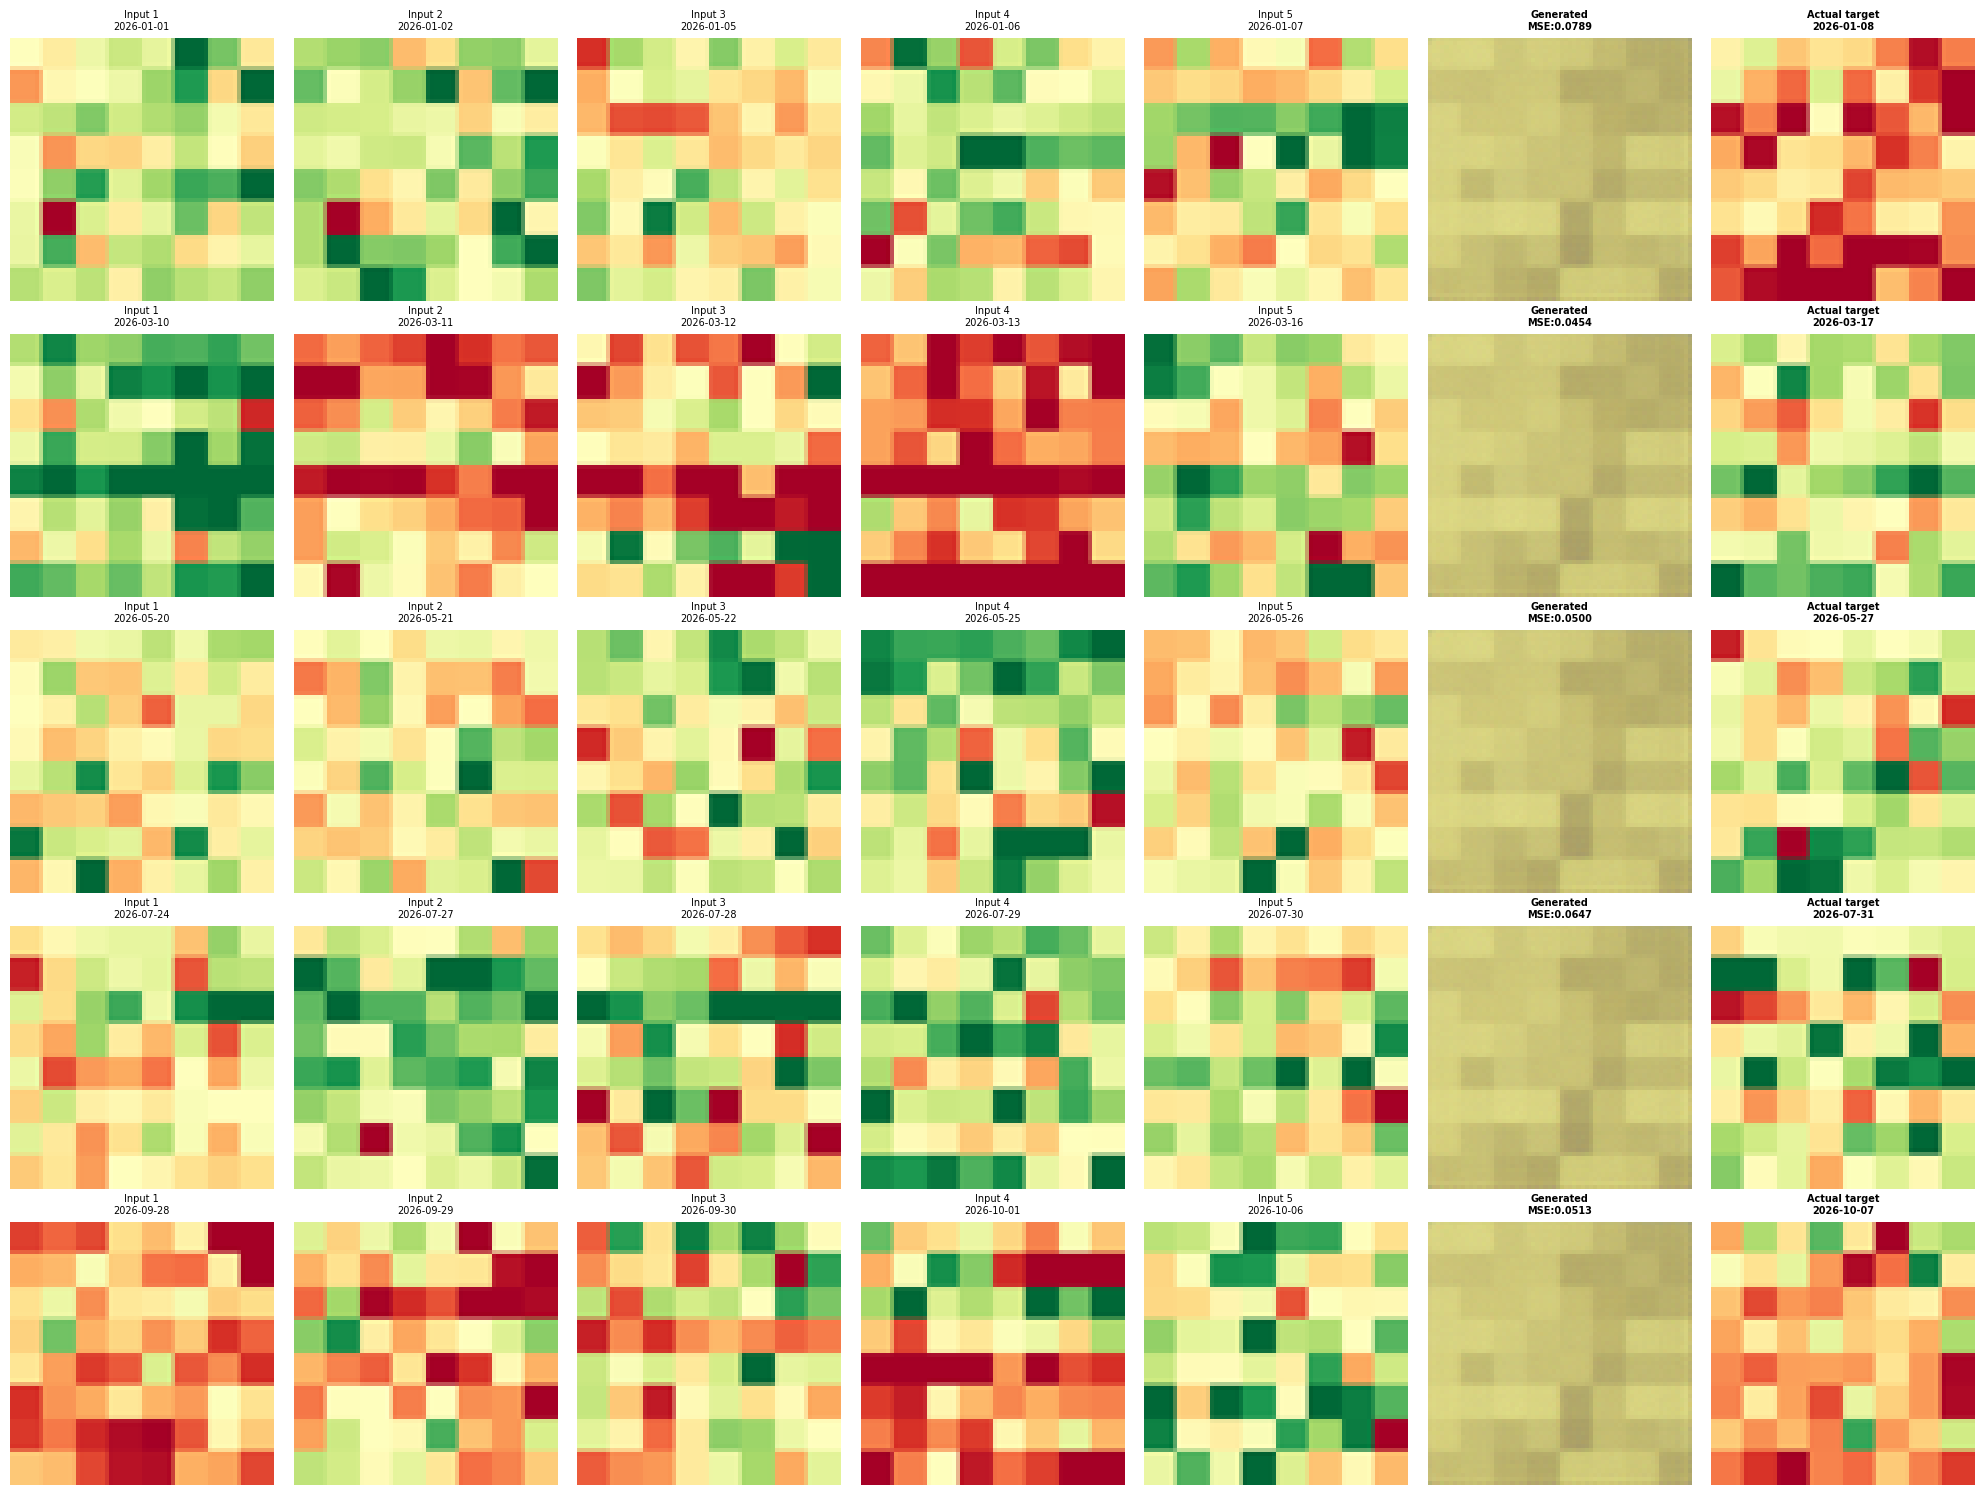

In [14]:
selected_indices = [int(i) for i in np.linspace(0, len(X_test) - 1, 5)]
decoder_layer = model.get_layer("Decoder")

plt.figure(figsize=(20, 15))
row_counter = 1

for idx in selected_indices:
    input_seqs = X_test[idx]
    actual_heatmap = y_test[idx]
    target_date = test_targets[idx]

    # Retrieve predicted heatmap deterministically using Decoder layer
    input_window = np.expand_dims(input_seqs, axis=0)
    _, z_mean, _ = model.predict(input_window, verbose=0)
    gen_heatmap = decoder_layer.predict(z_mean, verbose=0)[0]

    m = compute_metrics(actual_heatmap, gen_heatmap)

    # Retrieve sequential input dates associated with this sliding sequence
    target_pos = test_dates.index(target_date)
    input_dates_subset = test_dates[target_pos - CONFIG["SEQUENCE_LENGTH"]:target_pos]

    # Plot input heatmaps
    for step in range(CONFIG["SEQUENCE_LENGTH"]):
        plt.subplot(5, 7, row_counter)
        plt.imshow(input_seqs[step])
        plt.axis('off')
        plt.title(f"Input {step+1}\n{input_dates_subset[step].strftime('%Y-%m-%d')}", fontsize=7)
        row_counter += 1

    # Plot generated heatmap
    plt.subplot(5, 7, row_counter)
    plt.imshow(gen_heatmap)
    plt.axis('off')
    plt.title(f"Generated\nMSE:{m['MSE']:.4f}", fontsize=7, fontweight='bold')
    row_counter += 1

    # Plot actual target heatmap
    plt.subplot(5, 7, row_counter)
    plt.imshow(actual_heatmap)
    plt.axis('off')
    plt.title(f"Actual target\n{target_date.strftime('%Y-%m-%d')}", fontsize=7, fontweight='bold')
    row_counter += 1

plt.tight_layout()
plt.show()

## Cell 14: Unified Future Generator Function
Defines a robust helper function `generate_future_heatmap(previous_heatmaps, target_date)` to automate predictions safely using only historical sequences.

In [15]:
def generate_future_heatmap(previous_heatmaps, target_date):
    """
    Generates and returns the future predicted stock return heatmap deterministically via decoder.
    """
    prior_dates = sorted([d for d in previous_heatmaps.keys() if d < target_date])

    if len(prior_dates) < CONFIG["SEQUENCE_LENGTH"]:
        raise ValueError(f"Insufficient history available to support sequence of size {CONFIG['SEQUENCE_LENGTH']}")

    selected_dates = prior_dates[-CONFIG["SEQUENCE_LENGTH"]:]
    seq_inputs = np.array([previous_heatmaps[d] for d in selected_dates], dtype=np.float32)

    # Prepare model input processing
    model_in = np.expand_dims(seq_inputs, axis=0)

    # Get mean and decode deterministically
    _, z_mean, _ = model.predict(model_in, verbose=0)
    decoder_layer = model.get_layer("Decoder")
    gen_heatmap = decoder_layer.predict(z_mean, verbose=0)[0]

    # Plot generated output
    plt.figure(figsize=(4, 4))
    plt.imshow(gen_heatmap)
    plt.axis('off')
    plt.title(f"Forecasted Heatmap: {target_date.strftime('%Y-%m-%d')}")
    plt.show()

    return gen_heatmap

## Cell 15: Target Day Demo
Generates the future forecast for a simulated target date (the final date in the test split) using only its preceding sliding windows, and compares it to the actual target.

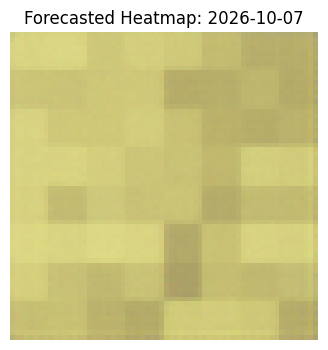

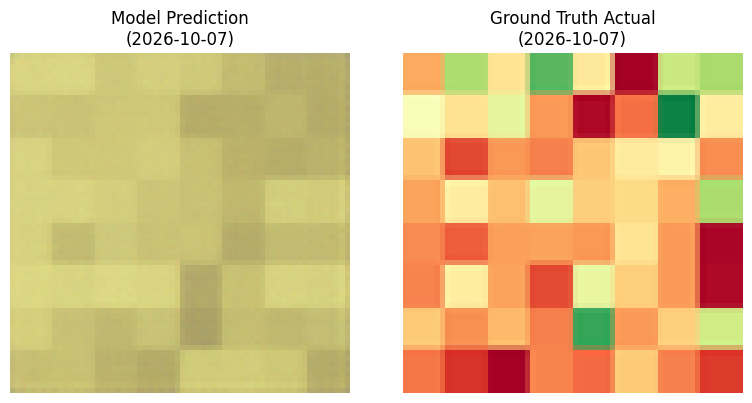

=== SIMULATED FUTURE DATE EVALUATION METRICS ===
MSE: 0.051344
MAE: 0.182010
SSIM: 0.224188
PSNR: 12.895077
Pixel_Corr: 0.627845
Sector_Similarity_MAE: 0.048576


In [16]:
# We simulate target forecasting using the final available trading date
simulated_target_date = test_targets[-1]

# Ensure we do not use the target image in generating predictions
pred_img = generate_future_heatmap(heatmap_dict, simulated_target_date)
real_img = heatmap_dict[simulated_target_date]

# Evaluate and plot actual vs generated outputs
demo_metrics = compute_metrics(real_img, pred_img)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(pred_img)
axes[0].set_title(f"Model Prediction\n({simulated_target_date.strftime('%Y-%m-%d')})")
axes[0].axis('off')

axes[1].imshow(real_img)
axes[1].set_title(f"Ground Truth Actual\n({simulated_target_date.strftime('%Y-%m-%d')})")
axes[1].axis('off')
plt.tight_layout()
plt.show()

print("=== SIMULATED FUTURE DATE EVALUATION METRICS ===")
for k, v in demo_metrics.items():
    print(f"{k}: {v:.6f}")

## Cell 16: Recursive Multi-step Forecasting
Implements recursive auto-regressive generation over horizons $T+1, T+2,$ and $T+3$ starting from a fixed input test window, visualizing performance decay.

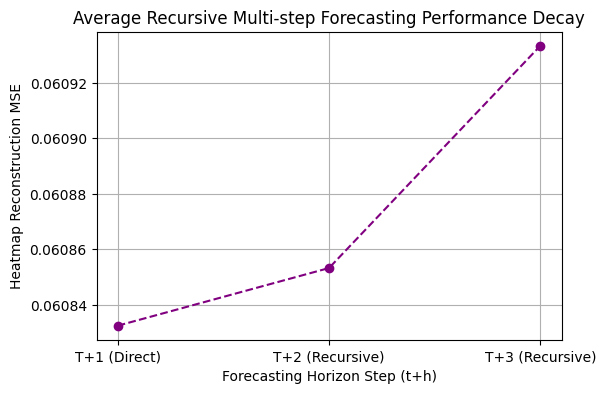

Average recursive multi-step forecast MSE list: [np.float32(0.060832378), np.float32(0.060853172), np.float32(0.060933307)]


In [17]:
recursive_mses_all = {1: [], 2: [], 3: []}
decoder_layer = model.get_layer("Decoder")

# Average the recursive MSE over all valid test sequences
num_eval = len(X_test) - 2

for base_idx in range(num_eval):
    input_seq = list(X_test[base_idx])  # sequential sequence list of 5 frames

    actuals = [
        y_test[base_idx],        # Horizon T+1
        y_test[base_idx + 1],    # Horizon T+2
        y_test[base_idx + 2]     # Horizon T+3
    ]

    for h_step in range(3):
        model_in = np.expand_dims(np.array(input_seq, dtype=np.float32), axis=0)
        _, z_mean, _ = model.predict(model_in, verbose=0)
        pred_h = decoder_layer.predict(z_mean, verbose=0)[0]

        # Compute horizon MSE and add
        actual_h = actuals[h_step]
        horizon_mse = np.mean((actual_h - pred_h) ** 2)
        recursive_mses_all[h_step + 1].append(horizon_mse)

        # Auto-regressively feed back decoded projection output
        input_seq.pop(0)
        input_seq.append(pred_h)

# Average horizons
avg_recursive_mses = [np.mean(recursive_mses_all[h]) for h in [1, 2, 3]]

# Plotting performance degradation over multi-step prediction averaged across test set
plt.figure(figsize=(6, 4))
plt.plot([1, 2, 3], avg_recursive_mses, marker='o', color='purple', linestyle='--')
plt.title("Average Recursive Multi-step Forecasting Performance Decay")
plt.xlabel("Forecasting Horizon Step (t+h)")
plt.ylabel("Heatmap Reconstruction MSE")
plt.xticks([1, 2, 3], ["T+1 (Direct)", "T+2 (Recursive)", "T+3 (Recursive)"])
plt.grid(True)
plt.show()

print("Average recursive multi-step forecast MSE list:", avg_recursive_mses)

## Cell 17: Sequence Length and Recurrent Cell Experiments
Trains short baseline models (10 epochs) across SEQUENCE_LENGTH values of 3, 5, and 7 using GRU structures and 5 using LSTM structure to create a comparison matrix.

In [18]:
import pandas as pd
import numpy as np
import tensorflow as tf

# List of configurations to run dynamically
experimental_configs = [
    {"seq_len": 3, "cell": "GRU"},
    {"seq_len": 5, "cell": "GRU"},
    {"seq_len": 7, "cell": "GRU"},
    {"seq_len": 5, "cell": "LSTM"}
]

experiment_results = []

for config_idx, run_cfg in enumerate(experimental_configs):
    seq_l = run_cfg["seq_len"]
    cell_t = run_cfg["cell"]
    print(f"\n>>> Starting 10 Epochs Experiment {config_idx+1}/4: Seq Length={seq_l}, Recurrent Cell={cell_t} <<<")

    # 1. Split and reconstruct sequence structures chronologically
    X_tr, y_tr, _ = build_sequences(train_dates, heatmap_dict, seq_l)
    X_te, y_te, _ = build_sequences(test_dates, heatmap_dict, seq_l)
    X_vl, y_vl, _ = build_sequences(val_dates, heatmap_dict, seq_l)

    # Create a local hyperparameter structure
    local_config = CONFIG.copy()
    local_config["SEQUENCE_LENGTH"] = seq_l
    local_config["TEMPORAL_MODEL"] = cell_t
    local_config["EPOCHS"] = 10

    # 2. Rebuild a fresh instance of the model network
    fresh_model = build_temporal_vae(local_config)
    fresh_beta = tf.Variable(0.0, dtype=tf.float32, trainable=False)
    fresh_train_model = VAEModel(fresh_model, fresh_beta)
    fresh_train_model.compile(optimizer=optimizers.Adam(learning_rate=local_config["LEARNING_RATE"]))

    # 3. Create datasets
    tr_ds = tf.data.Dataset.from_tensor_slices((X_tr, y_tr)).shuffle(len(X_tr), seed=SEED).batch(local_config["BATCH_SIZE"])
    vl_ds = tf.data.Dataset.from_tensor_slices((X_vl, y_vl)).batch(local_config["BATCH_SIZE"])

    # Define specific warm-up configuration locally
    class LocalKLCallback(callbacks.Callback):
        def on_epoch_begin(self, epoch, logs=None):
            if epoch < 10:
                current_beta = (epoch / 9.0) * local_config["BETA"]
            else:
                current_beta = local_config["BETA"]
            fresh_beta.assign(current_beta)

    # 4. Train the model for exactly 10 epochs
    fresh_train_model.fit(
        tr_ds,
        validation_data=vl_ds,
        epochs=10,
        callbacks=[LocalKLCallback()],
        verbose=0
    )

    # 5. Extract decoder and predict on test partition using deterministic mean vectors z_mean
    decoder_part = fresh_model.get_layer("Decoder")
    run_metrics = []
    for idx in range(len(X_te)):
        input_window = np.expand_dims(X_te[idx], axis=0)
        _, local_z_mean, _ = fresh_model.predict(input_window, verbose=0)
        gen_heat = decoder_part.predict(local_z_mean, verbose=0)[0]
        run_metrics.append(compute_metrics(y_te[idx], gen_heat))

    # Average metrics over test predictions
    avg_m = {k: np.mean([item[k] for item in run_metrics]) for k in run_metrics[0].keys()}

    # 6. Evaluate Training Set Mean baseline for this sequence configuration
    t_mean_heat = np.mean(y_tr, axis=0)
    baseline_metrics = [compute_metrics(y_te[idx], t_mean_heat) for idx in range(len(X_te))]
    baseline_mse = np.mean([b["MSE"] for b in baseline_metrics])

    experiment_results.append({
        "Model Recurrent Cell": cell_t,
        "Sequence Length": seq_l,
        "MSE": avg_m["MSE"],
        "MAE": avg_m["MAE"],
        "SSIM": avg_m["SSIM"],
        "PSNR": avg_m["PSNR"],
        "Train Mean Baseline MSE": baseline_mse
    })

exp_df = pd.DataFrame(experiment_results)
print("\n=== EXPERIMENT COMPARISON MATRIX ===")
display(exp_df)


>>> Starting 10 Epochs Experiment 1/4: Seq Length=3, Recurrent Cell=GRU <<<

>>> Starting 10 Epochs Experiment 2/4: Seq Length=5, Recurrent Cell=GRU <<<

>>> Starting 10 Epochs Experiment 3/4: Seq Length=7, Recurrent Cell=GRU <<<

>>> Starting 10 Epochs Experiment 4/4: Seq Length=5, Recurrent Cell=LSTM <<<

=== EXPERIMENT COMPARISON MATRIX ===


,Model Recurrent Cell,Sequence Length,MSE,MAE,SSIM,PSNR,Train Mean Baseline MSE
0,GRU,3,0.060547,0.188077,0.246878,12.494768,0.060301
1,GRU,5,0.060279,0.192320,0.248992,12.442212,0.060368
2,GRU,7,0.061103,0.186621,0.246287,12.474502,0.060403
3,LSTM,5,0.061237,0.200067,0.247776,12.294537,0.060368


## Cell 18: Model Saving and Final Conclusions
Saves model components and outputs to file directories and prints the structured academic conclusion.

In [19]:
import os
import numpy as np

os.makedirs("/content/models", exist_ok=True)
model.save("/content/models/temporal_vae_model.keras")

decoder_layer = model.get_layer("Decoder")
pred_list = []
for x in X_test:
    _, z_mean, _ = model.predict(np.expand_dims(x, axis=0), verbose=0)
    pred_list.append(decoder_layer.predict(z_mean, verbose=0)[0])
np.savez_compressed("/content/test_split_generated_heatmaps.npz", predictions=np.array(pred_list))
print("Successfully saved model and test output arrays.")

# Extract evaluations strictly computed over the test set
model_test_mse = model_avg["MSE"]
persistence_test_mse = persistence_avg["MSE"]
train_mean_test_mse = train_mean_avg["MSE"]
input_avg_test_mse = input_avg_avg["MSE"]

print("\n=== CONCLUSION ===")
print(f"Model Test MSE: {model_test_mse:.6f}")
print(f"Persistence Baseline Test MSE: {persistence_test_mse:.6f}")
print(f"Training Set Mean Baseline Test MSE: {train_mean_test_mse:.6f}")
print(f"Input Average Baseline Test MSE: {input_avg_test_mse:.6f}")

all_baselines = [persistence_test_mse, train_mean_test_mse, input_avg_test_mse]
best_baseline = min(all_baselines)

if model_test_mse < best_baseline:
    print("Assessment: outperformed all baselines")
elif abs(model_test_mse - train_mean_test_mse) <= (0.01 * train_mean_test_mse):
    print("Assessment: comparable to the training-mean baseline")
else:
    print("Assessment: The trained Temporal VAE model does NOT beat all baseline metrics under current constraints.")

Successfully saved model and test output arrays.

=== CONCLUSION ===
Model Test MSE: 0.060900
Persistence Baseline Test MSE: 0.113907
Training Set Mean Baseline Test MSE: 0.060368
Input Average Baseline Test MSE: 0.069184
Assessment: comparable to the training-mean baseline


In [1]:
from google.colab import files
up = files.upload()
name = list(up.keys())[0]
!jupyter nbconvert --to html "$name" --output out.html
files.download('out.html')

Saving Final_DeepLearning_Assignment (1).ipynb to Final_DeepLearning_Assignment (1).ipynb
[NbConvertApp] Converting notebook Final_DeepLearning_Assignment (1).ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 6 image(s).
[NbConvertApp] Writing 1261119 bytes to out.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>